In [230]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

In [231]:
import numpy as np
import matplotlib.pyplot as plt 
import copy
import time
from abc import ABC, abstractmethod
from typing import List, Tuple, Type
import qmcpy
from scipy.stats import norm 
from sklearn.gaussian_process import GaussianProcessRegressor

In [232]:
class GaussianProcessModel(GaussianProcessRegressor):
    def __init__(self,**kwargs):
        super().__init__(**kwargs)
        self.is_fit = False

    def fit(self, X, y):
        super().fit(X, y)
        self.is_fit = True
        return self 
    
    def mean(self, X: np.ndarray) -> np.ndarray:
        if not self.is_fit:
            raise RuntimeError("Model must be fit before calling mean.")
        return self.predict(X, return_std=False) 
    
    def variance(self, X: np.ndarray) -> np.ndarray:
        if not self.is_fit:
            raise RuntimeError("Model must be fit before calling variance.")
        _, std = self.predict(X, return_std=True)
        return std**2
    
    def sample(self, X: np.ndarray, n_samples: int=1) -> np.ndarray:
        if not self.is_fit:
            raise RuntimeError("Model must be fit before calling sample.")
        result = self.sample_y(X, n_samples=n_samples)
        # Ensure result is always an ndarray
        if isinstance(result, tuple):
            result = result[0]
        return np.asarray(result)
    
    def update(self, X_new: np.ndarray, y_new: np.ndarray):
        if not self.is_fit:
            raise RuntimeError("Model must be fit before calling update.")
        X_combined = np.concatenate((self.X_train_, X_new), axis=0)
        y_combined = np.concatenate((self.y_train_, y_new), axis=0)
        self.fit(X_combined, y_combined)
        return self

In [233]:
class Policy(ABC):
    def __init__(self, 
                 model: GaussianProcessModel, 
                 bounds: List[Tuple[float, float]] = None
            ):
        self.model = model
        self.bounds = bounds

    @abstractmethod
    def evaluate(self, points: np.ndarray) -> np.ndarray:
        """
        points: (M, D)
        return: (M,)
        """
        raise NotImplementedError 
    
    def optimize(self, n_grid_points: int=1000) -> np.ndarray:
        """
        return: (D,)
        """
        points = self.generate_sobol_points(n_grid_points)
        vals = self.evaluate(points)
        idx = np.argmax(vals)

        return points[[idx], : ] 

    def generate_sobol_points(self, num_points: int) -> np.ndarray:
        distribution = qmcpy.Sobol(dimension=len(self.bounds))
        pts01 = distribution.gen_samples(n=2 ** np.ceil(np.log2(num_points)))[:num_points]
        pts_scale = np.array([domain[1]-domain[0] for domain in self.bounds])
        pts_min = np.array([domain[0] for domain in self.bounds])
        return pts_min + pts_scale * pts01

In [234]:
class ExpectedImprovement(Policy):
    def __init__(self, 
                 model: GaussianProcessModel, 
                 bounds: List[Tuple[float, float]],
            ):
        super().__init__(model, bounds)

    def evaluate(self, points: np.ndarray) -> np.ndarray:
        """
        points: (M, D)
        return: (M,)
        """
        mu = self.model.mean(points)
        sigma2 = self.model.variance(points)
        sigma = np.sqrt(sigma2)
        f_min = self.model.predict(self.model.X_train_)[0].min()
        z = (f_min - mu)/np.fmax(sigma, 1e-8)
        cdf_z = norm.cdf(z)
        pdf_z = norm.pdf(z)

        return (sigma * np.fmax(0.0, z * cdf_z + pdf_z))

In [235]:
class MDPRollOut(Policy):
    def __init__(self, 
                 model: GaussianProcessModel, 
                 bounds: List[Tuple[float, float]],
                 horizon: int,
                 base_policy: Type[Policy], 
                 n_samples: int = int(1e2)
                ):
        super().__init__(model, bounds)
        self.horizon = horizon
        self.n_samples = n_samples
        self.base_policy = base_policy

    def evaluate(self, points: np.ndarray) -> np.ndarray:
        rewards = np.zeros((points.shape[0], self.n_samples,))
        for i in range(0, points.shape[0]):
            for j in range(0, self.n_samples):
                r = self.draw_from_policy(points[i].reshape(1, -1))
                rewards[i, j] = r.item() if isinstance(r, np.ndarray) else r

        return rewards.mean(axis=1)

    # Execute policy once using sequential draws from GPs
    def draw_from_policy(self, x):
        reward = 0.0
        model = copy.deepcopy(self.model)
        xi = copy.deepcopy(x)
        h = self.horizon
        is_terminal = True
        while(is_terminal):
            np.random.seed(int(time.time()))
            fi = model.sample(xi)
            f_min = self.model.y_train_.min().item()
            ri = max(f_min - fi, 0.0)
            reward += ri
            h = h - 1
            if h <= 0:
                is_terminal = False
            
            model.update(xi, fi)
            acqf = self.base_policy(model,self.bounds)
            xi = acqf.optimize()
        
        return reward

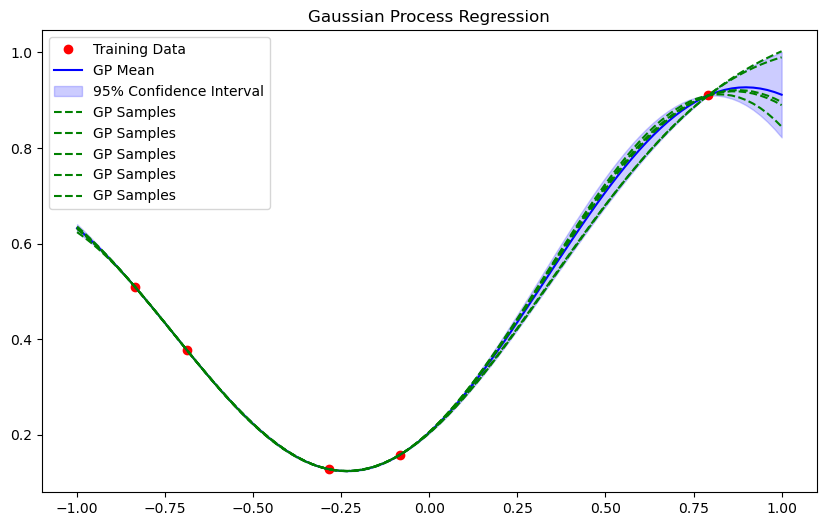

In [236]:
# Check GP model 
bounds = [(-1.0, 1.0)]
train_x = np.random.uniform(low=bounds[0][0], high=bounds[0][1], size=(5, 1))
train_y = np.sin(train_x) + (train_x-0.3)**2 + 0.1 * np.random.randn(*train_x.shape)

# train_x = np.linspace(0.15, 0.85, 2)[:, None]
# train_y = np.array([0, 0])[:, None]
# bounds = [(0.0, 1.0)]

gp = GaussianProcessModel().fit(train_x, train_y)
test_x = np.linspace(bounds[0][0], bounds[0][1], 100).reshape(-1, 1)
mean = gp.mean(test_x)
var = gp.variance(test_x)
samples = gp.sample(test_x, n_samples=5)
plt.figure(figsize=(10, 6))
plt.plot(train_x, train_y, 'ro', label='Training Data')
plt.plot(test_x, mean, 'b-', label='GP Mean')
plt.fill_between(test_x.flatten(), 
                 mean - 1.96 * np.sqrt(var), 
                 mean + 1.96 * np.sqrt(var), 
                 color='blue', 
                 alpha=0.2, 
                 label='95% Confidence Interval'
                )
plt.plot(test_x, samples, 'g--', label='GP Samples')
plt.legend()
plt.title('Gaussian Process Regression')
plt.show()

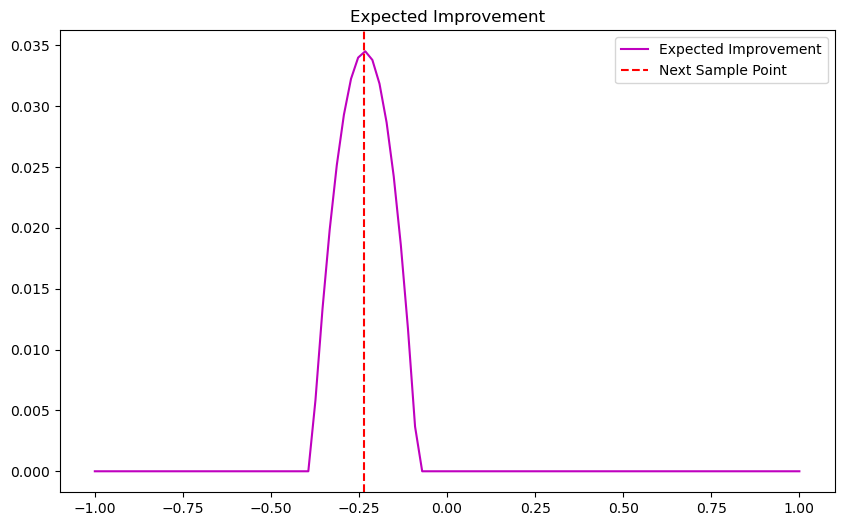

In [237]:
# Check EI policy
ei_policy = ExpectedImprovement(gp, bounds)
next_x = ei_policy.optimize()
ei_values = ei_policy.evaluate(test_x)
plt.figure(figsize=(10, 6))
plt.plot(test_x, ei_values, 'm-', label='Expected Improvement')
plt.axvline(next_x, color='r', linestyle='--', label='Next Sample Point')
plt.legend()
plt.title('Expected Improvement')
plt.show()

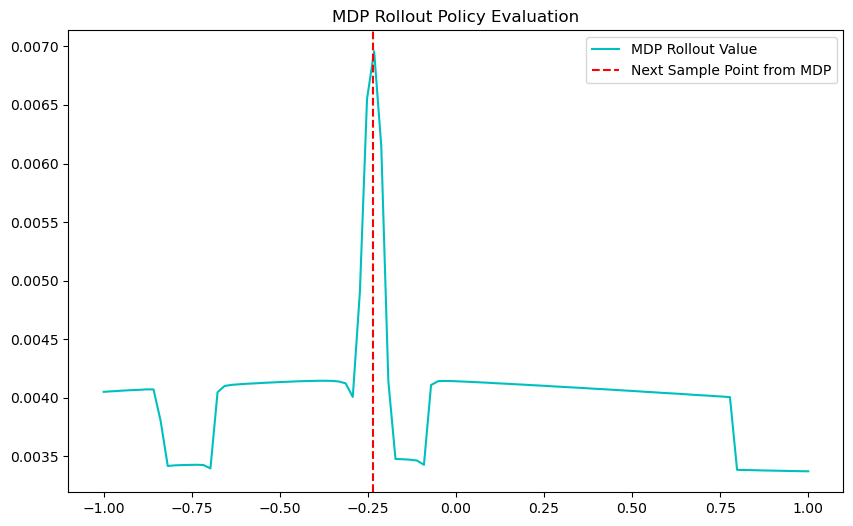

In [238]:
# Check MDP Rollout policy
mdp_policy = MDPRollOut(gp, 
                        bounds, 
                        horizon=2, 
                        base_policy=ExpectedImprovement,
                        n_samples=32
                    )   
next_x_mdp = mdp_policy.optimize()
mdp_values = mdp_policy.evaluate(test_x)
plt.figure(figsize=(10, 6))
plt.plot(test_x, mdp_values, 'c-', label='MDP Rollout Value')
plt.axvline(next_x_mdp, color='r', linestyle='--', label='Next Sample Point from MDP')
plt.legend()
plt.title('MDP Rollout Policy Evaluation')
plt.show()